# Analyse globale du changement climatique
Dans ce projet, nous utilisons les anomalies de température moyenne (terrestres et océaniques) pour prédire les futurs indices de température globale. Le jeu de données utilisé provient du site officiel de la NASA.

**Pourquoi ces données sont-elles des indicateurs fiables ?**
**Pourquoi considérons-nous que ces données sont représentatives du changement climatique et de l'évolution du climat ?**

La raison est simple : elles résultent de la fusion des températures de surface de la mer et de l'air au-dessus des terres. Cette approche combinée offre une vision globale et précise de la variation thermique à la surface de la planète. En utilisant des anomalies (l'écart par rapport à une moyenne de référence) plutôt que des températures brutes, nous pouvons identifier clairement les tendances de réchauffement à long terme, indépendamment des variations saisonnières ou géographiques locales.

# Importation des bibliothèques

Ici, nous commençons par importer l’ensemble des bibliothèques qui pourront nous être utiles pour la suite de l’analyse.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Analyse exploratoire des données

Nous commençons par importer, à partir d’un fichier CSV, les données contenant les anomalies de température.
Par la suite, nous affichons les premières statistiques descriptives. L’objectif ici est de vérifier que l’importation du fichier a bien réussi, d’examiner la structure générale des données ainsi que le type des variables.

Les variables n’étant pas indépendantes et identiquement distribuées dans le cas des séries temporelles, nous interprétons avec beaucoup de précaution des indicateurs tels que la moyenne, l’écart-type ou les quartiles. En effet, ces statistiques ne tiennent pas compte de la dimension temporelle ni d’une éventuelle composante saisonnière pouvant être présente dans les données. 

In [2]:
data = pd.read_csv( 'AnomaliesDeTempératureGlobale.csv' , skiprows=1)


In [3]:
data.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-.17,-.10,-.21,-.19,-.11,-.15,-.24,-.22,-.18,-.17,***,***,-.12,-.17,-.20
1,1881,-0.20,-0.14,0.03,.05,.06,-.19,.00,-.04,-.16,-.22,-.19,-.07,-.09,-.10,-.17,.04,-.08,-.19
2,1882,0.16,0.13,0.04,-.16,-.14,-.23,-.17,-.08,-.15,-.24,-.17,-.37,-.11,-.09,.07,-.09,-.16,-.19
3,1883,-0.29,-0.37,-0.12,-.19,-.18,-.07,-.08,-.14,-.22,-.12,-.24,-.11,-.18,-.20,-.34,-.16,-.10,-.20
4,1884,-0.13,-0.08,-0.36,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.34,-.31,-.29,-.27,-.11,-.37,-.31,-.29


Les variables **Jan, …, Dec** représentent les anomalies de température observées pour chacun des mois de l’année.

Les variables **J-D et D-N** correspondent aux moyennes annuelles des anomalies.

**J-D** représente la moyenne calculée sur le cycle conventionnel, allant de janvier à décembre.

**D-N** représente la moyenne calculée sur le cycle météorologique, allant de décembre à novembre de l’année suivante.

Les variables **DJF, MAM, JJA et SON** représentent les moyennes trimestrielles (saisonnières) des anomalies de température.

**DJF** correspond à la moyenne des mois décembre, janvier et février,

**MAM** à celle de mars, avril et mai,

**JJA** à celle de juin, juillet et août,

**SON** à celle de septembre, octobre et novembre.

In [4]:
data.tail()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
141,2021,0.82,0.64,0.89,.76,.80,.85,.92,.81,.92,.99,.92,.88,.85,.84,.75,.82,.86,.94
142,2022,0.91,0.89,1.05,.83,.84,.93,.94,.95,.89,.97,.73,.80,.89,.90,.89,.91,.94,.86
143,2023,0.88,0.97,1.23,.99,.94,1.09,1.19,1.19,1.48,1.34,1.42,1.37,1.17,1.13,.88,1.06,1.16,1.41
144,2024,1.26,1.45,1.39,1.32,1.16,1.24,1.20,1.30,1.23,1.34,1.29,1.27,1.29,1.30,1.36,1.29,1.25,1.29
145,2025,1.37,1.26,1.36,***,***,***,***,***,***,***,***,***,***,***,1.30,***,***,***


In [5]:
data.describe()

,Year,Jan,Feb,Mar
count,146.000000,146.000000,146.000000,146.000000
mean,1952.500000,0.077808,0.086027,0.103836
std,42.290661,0.447766,0.452429,0.459046
min,1880.000000,-0.810000,-0.640000,-0.640000
25%,1916.250000,-0.247500,-0.240000,-0.230000
50%,1952.500000,-0.010000,-0.035000,0.015000
75%,1988.750000,0.320000,0.397500,0.345000
max,2025.000000,1.370000,1.450000,1.390000


Ici, nous obtenons l’affichage des trois premiers mois, car nous n’avons pas encore transformé les autres variables en valeurs numériques de type float.
Cependant, nous observons que la plus grande anomalie enregistrée sur la période allant de 1880 à 2024 est de 1,37 pour le mois de janvier, 1,45 pour le mois de février et 1,39 pour le mois de mars. La plus faible anomalie observée en janvier est de −0,81.

Pour les raisons évoquées précédemment, nous rappelons que les variables n’étant pas indépendantes et identiquement distribuées, nous nous abstenons de toute interprétation des statistiques telles que la moyenne, la variance ou les quartiles à ce stade de l’analyse. 

In [6]:
data.shape

(146, 19)

In [7]:
data=data.drop(145)

In [8]:
data.describe()

,Year,Jan,Feb,Mar
count,145.000000,145.000000,145.000000,145.000000
mean,1952.000000,0.068897,0.077931,0.095172
std,42.001984,0.436132,0.443256,0.448501
min,1880.000000,-0.810000,-0.640000,-0.640000
25%,1916.000000,-0.250000,-0.240000,-0.230000
50%,1952.000000,-0.010000,-0.040000,0.010000
75%,1988.000000,0.320000,0.390000,0.330000
max,2024.000000,1.260000,1.450000,1.390000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    145 non-null    int64  
 1   Jan     145 non-null    float64
 2   Feb     145 non-null    float64
 3   Mar     145 non-null    float64
 4   Apr     145 non-null    object 
 5   May     145 non-null    object 
 6   Jun     145 non-null    object 
 7   Jul     145 non-null    object 
 8   Aug     145 non-null    object 
 9   Sep     145 non-null    object 
 10  Oct     145 non-null    object 
 11  Nov     145 non-null    object 
 12  Dec     145 non-null    object 
 13  J-D     145 non-null    object 
 14  D-N     145 non-null    object 
 15  DJF     145 non-null    object 
 16  MAM     145 non-null    object 
 17  JJA     145 non-null    object 
 18  SON     145 non-null    object 
dtypes: float64(3), int64(1), object(15)
memory usage: 21.7+ KB


Puisque notre jeu de données ne comporte pas l’année 1979, nous observons deux valeurs manquantes au niveau des moyennes annuelles du cycle météorologique et de certaines moyennes saisonnières.
Afin de traiter ces valeurs manquantes, nous choisissons de les remplacer par la moyenne annuelle du cycle conventionnel (J–D). Ce choix est justifié par le fait que l’anomalie de température du mois de décembre ne diffère généralement pas fortement de celle du mois de janvier, ce qui limite l’introduction d’un biais important.

Par ailleurs, pour l’année 2025, nous ne disposons que des anomalies correspondant aux trois premiers mois. Afin d’éviter tout biais lié à une information incomplète, nous optons pour la suppression de cette année du jeu de données.

Enfin, nous transformons l’ensemble des variables en valeurs numériques de type flottant, afin de permettre les traitements statistiques et temporels ultérieurs.

In [11]:
mean_j_d= data.loc[0, ['Jan', 'Feb',	'Mar'	,'Apr',	'May'	
                       ,'Jun',	'Jul',	'Aug'	,'Sep'	,'Oct',	'Nov'	,'Dec']].astype(float).mean()
data=data.replace( '***' , mean_j_d)

In [12]:
for col in data.columns[1:]:
    data[col] = data[col].astype(float)

In [13]:
data

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.09,-0.17,-0.10,-0.21,-0.19,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,-0.175,-0.175,-0.12,-0.17,-0.20
1,1881,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.100,-0.170,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.11,-0.090,0.070,-0.09,-0.16,-0.19
3,1883,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.200,-0.340,-0.16,-0.10,-0.20
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.270,-0.110,-0.37,-0.31,-0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,2020,1.18,1.24,1.18,1.12,1.00,0.92,0.89,0.86,0.97,0.87,1.09,0.80,1.01,1.040,1.180,1.10,0.89,0.98
141,2021,0.82,0.64,0.89,0.76,0.80,0.85,0.92,0.81,0.92,0.99,0.92,0.88,0.85,0.840,0.750,0.82,0.86,0.94
142,2022,0.91,0.89,1.05,0.83,0.84,0.93,0.94,0.95,0.89,0.97,0.73,0.80,0.89,0.900,0.890,0.91,0.94,0.86
143,2023,0.88,0.97,1.23,0.99,0.94,1.09,1.19,1.19,1.48,1.34,1.42,1.37,1.17,1.130,0.880,1.06,1.16,1.41


In [15]:
data.describe()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,1952.000000,0.068897,0.077931,0.095172,0.067931,0.058207,0.046069,0.069793,0.068345,0.073310,0.098759,0.091724,0.066138,0.073379,0.072724,0.067759,0.073793,0.061724,0.087862
std,42.001984,0.436132,0.443256,0.448501,0.410954,0.390521,0.390801,0.371866,0.388764,0.389991,0.395937,0.403919,0.420156,0.394235,0.393629,0.419145,0.412203,0.380255,0.391234
min,1880.000000,-0.810000,-0.640000,-0.640000,-0.600000,-0.560000,-0.530000,-0.520000,-0.550000,-0.590000,-0.590000,-0.580000,-0.820000,-0.500000,-0.500000,-0.680000,-0.580000,-0.500000,-0.520000
25%,1916.000000,-0.250000,-0.240000,-0.230000,-0.250000,-0.240000,-0.250000,-0.190000,-0.220000,-0.200000,-0.200000,-0.180000,-0.220000,-0.200000,-0.220000,-0.240000,-0.260000,-0.230000,-0.190000
50%,1952.000000,-0.010000,-0.040000,0.010000,-0.030000,-0.040000,-0.050000,-0.030000,-0.040000,-0.060000,0.010000,0.020000,-0.040000,-0.030000,-0.050000,-0.030000,-0.030000,-0.040000,-0.020000
75%,1988.000000,0.320000,0.390000,0.330000,0.290000,0.280000,0.260000,0.260000,0.260000,0.250000,0.260000,0.280000,0.320000,0.310000,0.290000,0.320000,0.310000,0.280000,0.280000
max,2024.000000,1.260000,1.450000,1.390000,1.320000,1.160000,1.240000,1.200000,1.300000,1.480000,1.340000,1.420000,1.370000,1.290000,1.300000,1.360000,1.290000,1.250000,1.410000


Ici, nous créons une colonne Date au format datetime et nous la définissons comme indice de notre DataFrame, afin que les données intègrent pleinement leur dimension temporelle.
Par la suite, la colonne Year, devenue redondante, est supprimée.

In [12]:
data['date'] = pd.to_datetime( data['Year'] ,format = '%Y')  
data= data.set_index('date')
data = data.drop( columns=['Year'], axis=1)

In [13]:
data

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
date,,,,,,,,,,,,,,,,,,
1880-01-01,-0.19,-0.25,-0.09,-0.17,-0.10,-0.21,-0.19,-0.11,-0.15,-0.24,-0.22,-0.18,-0.17,-0.175,-0.175,-0.12,-0.17,-0.20
1881-01-01,-0.20,-0.14,0.03,0.05,0.06,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.07,-0.09,-0.100,-0.170,0.04,-0.08,-0.19
1882-01-01,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.11,-0.090,0.070,-0.09,-0.16,-0.19
1883-01-01,-0.29,-0.37,-0.12,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.12,-0.24,-0.11,-0.18,-0.200,-0.340,-0.16,-0.10,-0.20
1884-01-01,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.270,-0.110,-0.37,-0.31,-0.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-01,1.18,1.24,1.18,1.12,1.00,0.92,0.89,0.86,0.97,0.87,1.09,0.80,1.01,1.040,1.180,1.10,0.89,0.98
2021-01-01,0.82,0.64,0.89,0.76,0.80,0.85,0.92,0.81,0.92,0.99,0.92,0.88,0.85,0.840,0.750,0.82,0.86,0.94
2022-01-01,0.91,0.89,1.05,0.83,0.84,0.93,0.94,0.95,0.89,0.97,0.73,0.80,0.89,0.900,0.890,0.91,0.94,0.86


# Data visualisation

Il est question ici de réaliser une analyse exploratoire visuelle de nos données afin d’identifier, de manière graphique, leur structure ainsi que les tendances sous-jacentes.
Une telle visualisation a également pour objectif d’orienter le choix du modèle à utiliser pour la prédiction des valeurs futures.

C:\Users\USER\AppData\Local\Temp\ipykernel_12188\14926456.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


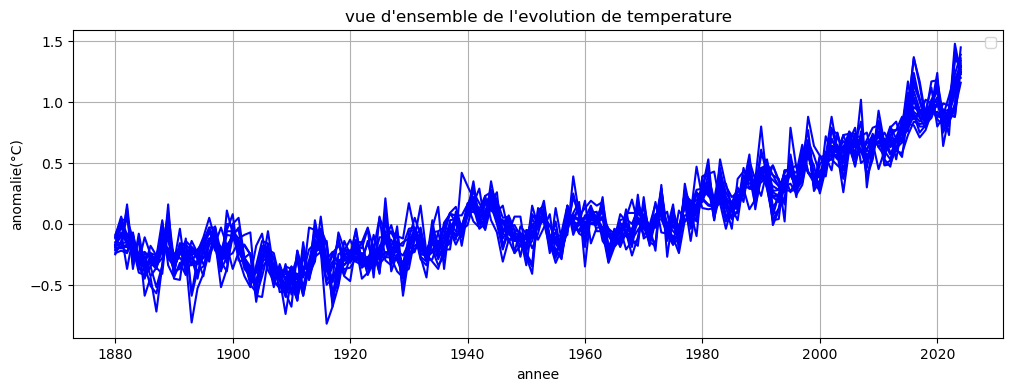

In [14]:
plt.figure(figsize=(12,4))
plt.plot (data , "b")
plt.xlabel('annee')
plt.ylabel('anomalie(°C)')
plt.title("vue d'ensemble de l'evolution de temperature")
plt.legend()
plt.grid(True)



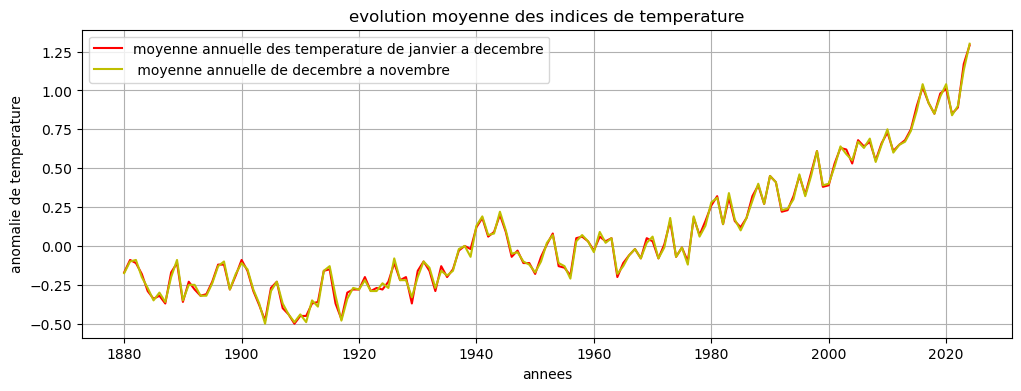

In [15]:
plt.figure( figsize=(12,4))
plt.plot( data['J-D'] , 'r' , label= 'moyenne annuelle des temperature de janvier a decembre')
plt.plot (data['D-N'] , 'y', label =' moyenne annuelle de decembre a novembre')
plt.xlabel('annees')
plt.ylabel('anomalie de temperature')
plt.title('evolution moyenne des indices de temperature')
plt.legend()
plt.grid(True)


On observe que notre série temporelle suit une tendance globalement croissante. Cela suggère qu’au fil des années, les anomalies de température n’ont cessé d’augmenter, traduisant une élévation progressive de la température globale. Cette évolution constitue un signal fort du changement climatique.

En effet, autour de l’année 1880, l’anomalie de température était d’environ −0,25. À partir des années 1920, on observe une nette accélération, avec des anomalies atteignant environ 0,25, soit approximativement le double des valeurs observées à la fin du XIXᵉ siècle. Cette tendance se poursuit jusqu’à atteindre environ 1,24 en 2024.

Cette évolution met en évidence une accélération récente du réchauffement, soulignant l’ampleur et la persistance du phénomène observé sur le long terme.

**Par la suite, nous utilisons la matrice de corrélation afin d’évaluer de manière quantitative les relations existant entre les différents mois et d’identifier la dynamique temporelle qui s’y opère.**

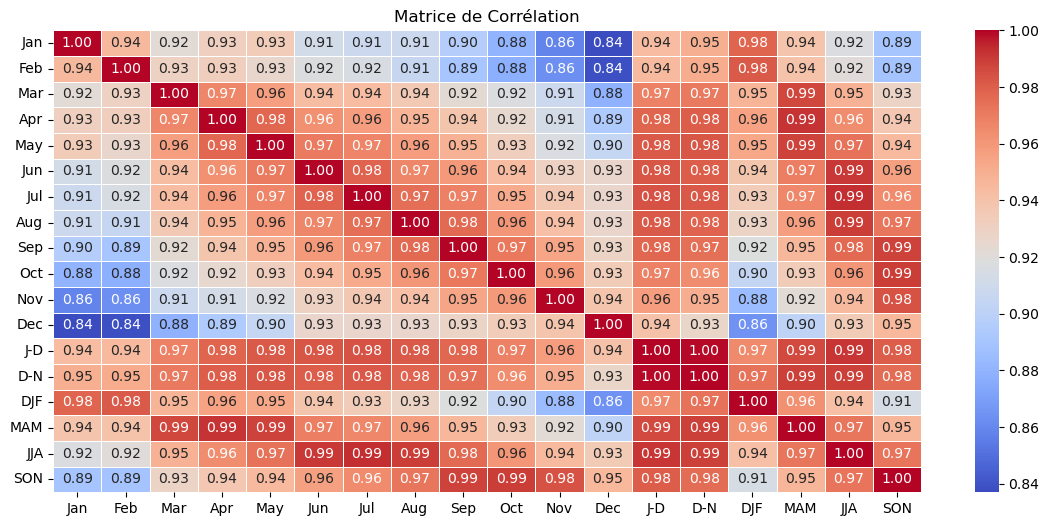

In [16]:
matrice_de_corelation = data.corr()
plt.figure(figsize=(14, 6))
sns.heatmap(matrice_de_corelation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

Nous observons des corrélations très fortes entre les différents mois. La plus faible corrélation est de 0,84, ce qui est très informatif. Un fait marquant est que toutes les corrélations sont positives, ce qui suggère que les indices de température d’un mois influencent positivement ceux des autres mois.

À titre d’exemple, la corrélation entre les mois d’avril et d’octobre est de 0,92, ce qui indique que lorsque l’indice de température d’avril augmente, l’indice d’octobre tend également à augmenter, reflétant une forte cohérence saisonnière.

Ces résultats confirment l’hypothèse d’une augmentation globale de la température, puisque toutes les corrélations sont élevées et positives, traduisant une tendance homogène à la hausse sur l’ensemble de l’année.

**Afin d’examiner les propriétés statistiques de notre série**, nous allons calculer les **moyennes mobiles et les variances mobiles** afin de vérifier si elles restent **constantes dans le temps**.

En effet, les modèles de séries temporelles reposent sur l’hypothèse de **stationnarité**, c’est-à-dire que certaines propriétés statistiques , en particulier la moyenne et la variance  doivent être constantes, et que la covariance entre deux valeurs de la série ne doit **dépendre que de l’écart temporel entre elles, et non du temps absolu**.

In [17]:
data_mois = data[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']].stack()
#transforme le tableau large (où chaque mois est une colonne) en 
#une série longue (où tous les mois sont les uns en dessous des autres).
moyenne_mobile = data_mois.rolling( window=12, center=True).mean() #permet de lisser les donnees pour annuler les bruit les variation brrusque pour faire apparete le tendences de fond

C:\Users\USER\AppData\Local\Temp\ipykernel_12188\3926792644.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


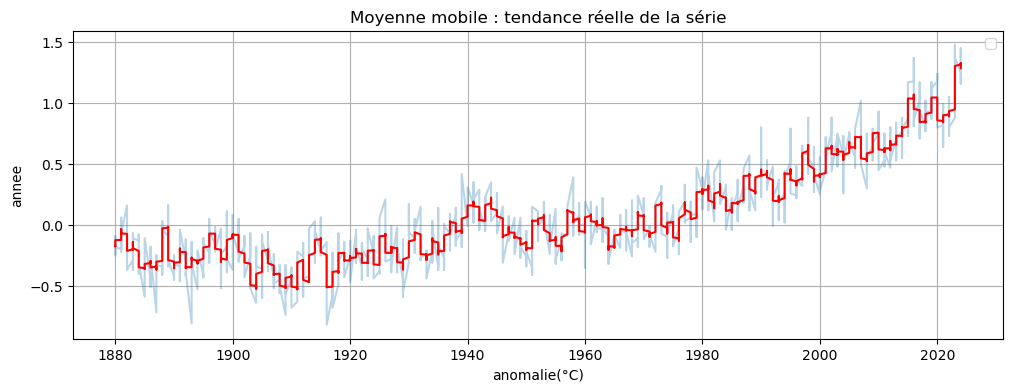

In [18]:
plt.figure(figsize=(12,4))
plt.plot(data_mois.index.get_level_values(0), data_mois.values, alpha=0.3)
plt.plot(data_mois.index.get_level_values(0), moyenne_mobile, color='red')
plt.xlabel('anomalie(°C)')
plt.ylabel('annee')
plt.legend()
plt.title('Moyenne mobile : tendance réelle de la série')
plt.grid(True)
#Comme on a utilisé stack(), l'index devient complexe (un MultiIndex).
#Cette commande dit à Python : "Prends le premier niveau de l'index (les dates/années) 
#pour l'axe horizontal X (0) et 1 va etre jan,fev...

On observe que la moyenne mobile (représentée par la courbe rouge) augmente avec le temps, ce qui suggère que notre série **n’est pas stationnaire**.

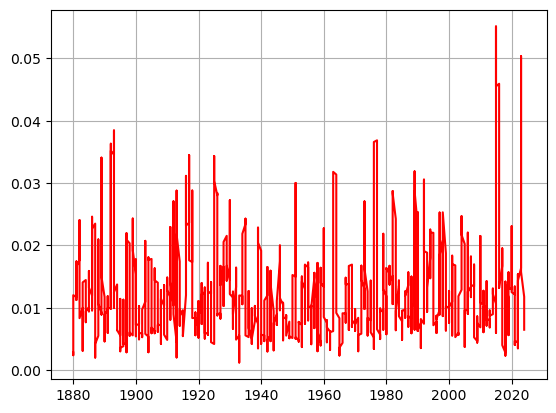

In [49]:
variance_mobile = data_mois.rolling( window=12, center=True).var()
plt.plot(data_mois.index.get_level_values(0), variance_mobile, color='red')
plt.grid(True)

Tout comme pour la moyenne mobile, on constate que la variance mobile n’est pas constante dans le temps. En effet, on observe des fluctuations d’amplitudes très variables autour de zéro, ce qui confirme de manière visuelle l’hypothèse de **non-stationnarité de la série**.

In [92]:
data_mois.index
data_mois

date
1880-01-01   -0.19
1880-01-01   -0.25
1880-01-01   -0.09
1880-01-01   -0.17
1880-01-01   -0.10
              ... 
2024-01-01    1.30
2024-01-01    1.23
2024-01-01    1.34
2024-01-01    1.29
2024-01-01    1.27
Length: 1740, dtype: float64

**Après avoir évalué visuellement la stationnarité, il est important de s’intéresser à la saisonnalité de la série.**

Pour répondre à cette question, nous utilisons une décomposition saisonnière, qui permet de détecter la structure interne de notre série. Plus précisément, cette approche consiste à observer :

**la tendance à long terme**,

**la saisonnalité, c’est-à-dire les cycles qui se répètent régulièrement**,

et enfin **le bruit résiduel présent dans les données**.

Cette étape permet de mieux comprendre la dynamique de la série et d’orienter le **choix des modèles de prévision appropriés**.

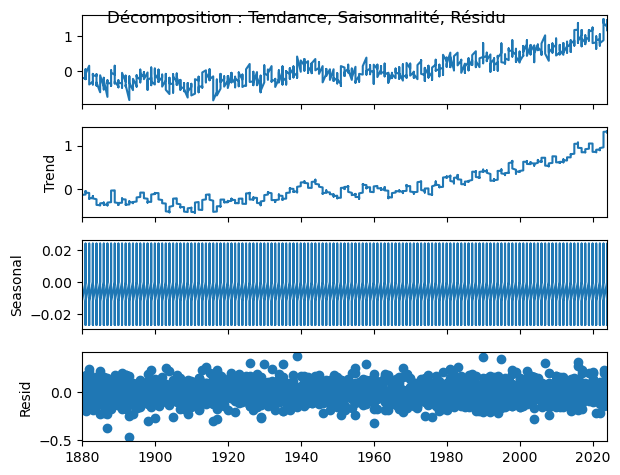

In [57]:
# stack les colonnes mensuelles
data_mois = data[['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']].stack()

# garder uniquement la date comme index
data_mois.index = pd.to_datetime(data_mois.index.get_level_values(0))

# s'assurer que ce sont des floats
data_mois = pd.to_numeric(data_mois, errors='coerce')  # convertit tout en nombre, NaN si impossible

# maintenant la décomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    data_mois,
    model='additive',
    period=12
)

decomposition.plot()
plt.suptitle('Décomposition : Tendance, Saisonnalité, Résidu')
plt.show()


Nous observons une tendance croissante dans notre série ainsi qu’une répétition régulière des cycles, ce qui suggère **la présence d’une composante saisonnière dans les données**. 

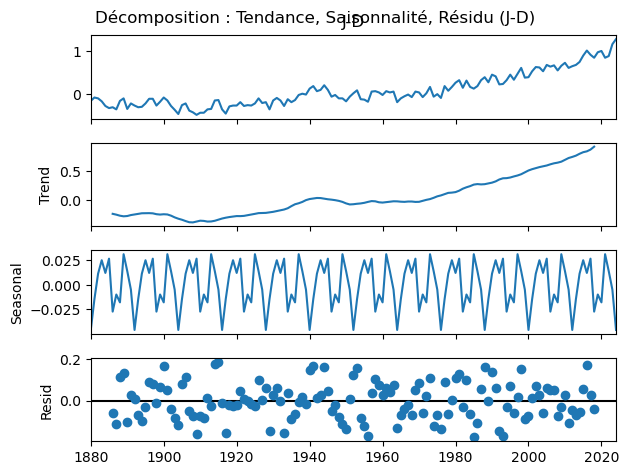

In [48]:
data_mean = data['J-D']
decomposition_mean = seasonal_decompose ( data_mean, model='additive', period=12)
decomposition_mean.plot()
plt.suptitle('Décomposition : Tendance, Saisonnalité, Résidu (J-D)')
plt.show()

Nous observons une tendance croissante dans notre série ainsi qu’une répétition régulière des cycles, ce qui suggère la présence d’une composante saisonnière dans les données.

**Ces analyses exploratoires visuelles nous ont permis de mettre en évidence plusieurs points importants** :

**une tendance croissante de notre série**, suggérant une augmentation globale de la température au fil du temps,

**la présence d’une composante saisonnière**,

et **des propriétés statistiques non stationnaires, ce qui implique qu’une différenciation est nécessaire**.

À l’issue de ces analyses, nous pouvons déjà conclure que le modèle le plus approprié pour la modélisation et la prévision future de cette série est **le modèle SARIMA**. 

# Modélisation

Il s’agit ici d’utiliser des **tests statistiques** appropriés pour confirmer ou infirmer les hypothèses émises précédemment concernant les **propriétés de notre série**.
Par la suite, nous utiliserons les courbes d’**autocorrélation (ACF)** et d’**autocorrélation partielle (PACF)** pour déterminer les paramètres du modèle **SARIMA**, avant de procéder à la modélisation proprement dite. 

In [60]:
data_mois

date
1880-01-01   -0.19
1880-01-01   -0.25
1880-01-01   -0.09
1880-01-01   -0.17
1880-01-01   -0.10
              ... 
2024-01-01    1.30
2024-01-01    1.23
2024-01-01    1.34
2024-01-01    1.29
2024-01-01    1.27
Length: 1740, dtype: float64

<Axes: xlabel='date'>

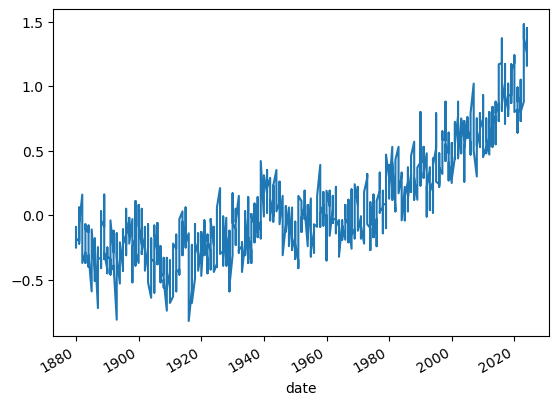

In [64]:
series_adf = data_mois.squeeze()
series_adf.plot()

In [67]:
test_ADF = adfuller(series_adf)
print('ADF Statistic:', test_ADF[0])
print('p-value:', test_ADF[1])
print('Critical Values:', test_ADF[4])

ADF Statistic: 0.24164514611915613
p-value: 0.9745029669785676
Critical Values: {'1%': np.float64(-3.434168725808674), '5%': np.float64(-2.8632267535965252), '10%': np.float64(-2.567667981283309)}


In [69]:
data_diff = data_mois.diff().dropna()
series_adf_diff= data_diff.squeeze()
test_ADF_diff= adfuller(series_adf_diff)
print('ADF Statistic:', test_ADF_diff[0])
print('p-value:', test_ADF_diff[1])
print('Critical Values:', test_ADF_diff[4])

ADF Statistic: -12.249068540674203
p-value: 9.632911908989793e-23
Critical Values: {'1%': np.float64(-3.434168725808674), '5%': np.float64(-2.8632267535965252), '10%': np.float64(-2.567667981283309)}


<Axes: xlabel='date'>

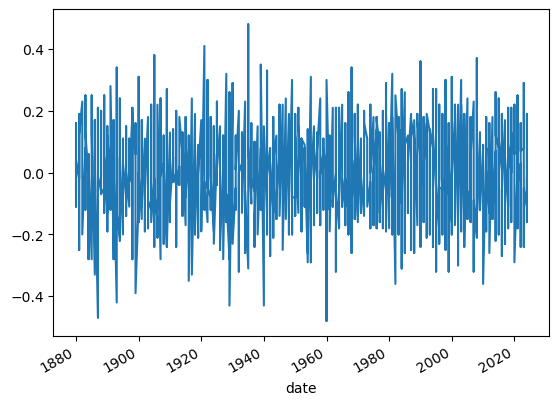

In [70]:
data_diff.plot()


Text(0.5, 1.0, "courbr d'autocorreltion")

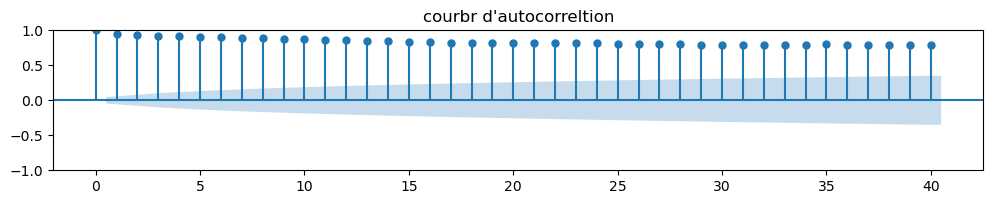

In [79]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plot_acf( series_adf, ax=plt.gca(), lags=40)
plt.title("courbr d'autocorreltion")            

Text(0.5, 1.0, 'autocorrelation partielle')

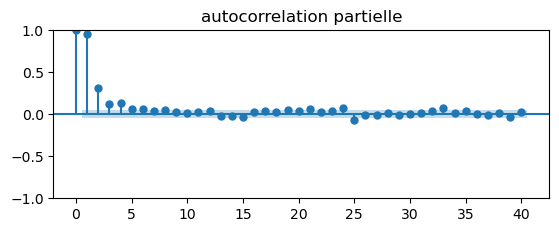

In [82]:
#plt.figure(figsize(12,4))
plt.subplot(2,1,2)
plot_pacf(series_adf, ax=plt.gca(), lags=40)
plt.title("autocorrelation partielle")

Text(0.5, 1.0, "courbe d'autocorreltion")

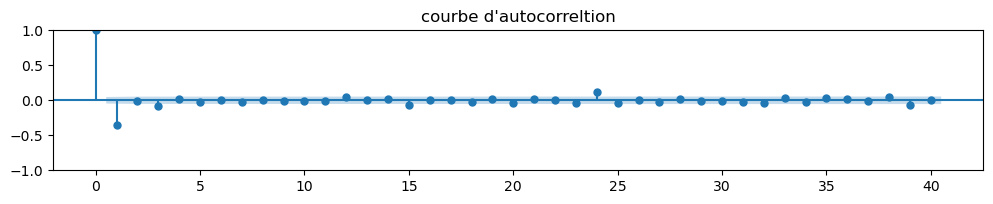

In [85]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plot_acf( data_diff, ax=plt.gca(), lags=40)
plt.title("courbe d'autocorreltion")

On observe que juste après le pas zéro, la fonction d’autocorrélation présente une décroissance rapide, et qu’une barre dépasse significativement l’intervalle de confiance. Au pas 24, une autre barre dépasse également l’intervalle de manière notable.

On peut donc supposer un ordre MA q=1  c’est-à-dire considérer simplement la première barre significative. Par la suite, il est possible de tester 
q=2 et d’évaluer l’impact sur la performance du modèle.

Text(0.5, 1.0, "courbe d'autocorreltion partielle")

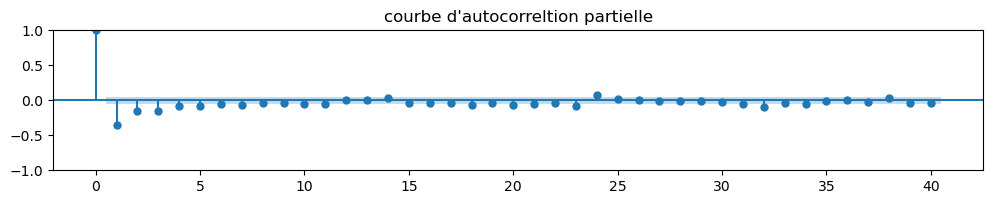

In [87]:
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plot_pacf( data_diff, ax=plt.gca(), lags=40)
plt.title("courbe d'autocorreltion partielle")

Tout comme pour la courbe d’autocorrélation, on observe ici une décroissance rapide après le lag 0, avec environ trois barres significatives dépassant l’intervalle de confiance, dont une est particulièrement notable.

Cela suggère que l’ordre AR pourrait être 

p=3. Par la suite, il sera également possible de tester 

p=1 et d’évaluer l’impact sur la performance de la prévision.

**Le meilleur moyen d’évaluer un modèle de séries temporelles est de réaliser des prévisions sur une période pour laquelle les valeurs réelles sont déjà connues**.

Pour ce faire, nous allons **découper notre jeu de données en deux parties** :

la première partie, allant de **1880 à 2017**, servira à **entraîner le modèle**,

la deuxième partie, allant de **2018 à 2024**, sera utilisée pour **tester les prévisions**, puisque nous connaissons déjà les valeurs réelles sur cette période.

De cette manière, nous pourrons apprécier de manière objective la qualité de prédiction de notre modèle.

In [192]:
# On s'arrête à l'année 2017 incluse
data_train = data.loc['1880':'2017',:'Dec'] 
# On commence à l'année 2018
data_test = data.loc['2018':,:'Dec']

data_train_ok = data_train.stack()
data_tes_ok = data_test.stack()

In [193]:
model=ARIMA(data_train_ok, order=(1,1,1))
resultats=model.fit()
resultats.summary()

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1656
Model:                 ARIMA(1, 1, 1)   Log Likelihood                1315.428
Date:                Fri, 06 Feb 2026   AIC                          -2624.856
Time:                        10:23:37   BIC                          -2608.621
Sample:                             0   HQIC                         -2618.838
                               - 1656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3327      0.037      9.014      0.000       0.260       0.405
ma.L1         -0.7784      0.025    -30.673      0.000      -0.828      -0.729
sigma2         0.0119      0.000     33.451      0.000       0.011       0.013
===================================================================================
Ljung-Box (L1) (Q):                   1.09   Jarque-Bera (JB):                39.03
Prob(Q):                              0.30   Prob(JB):                         0.00
Heteroskedasticity (H):               1.06   Skew:                            -0.09
Prob(H) (two-sided):                  0.47   Kurtosis:                         3.73
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

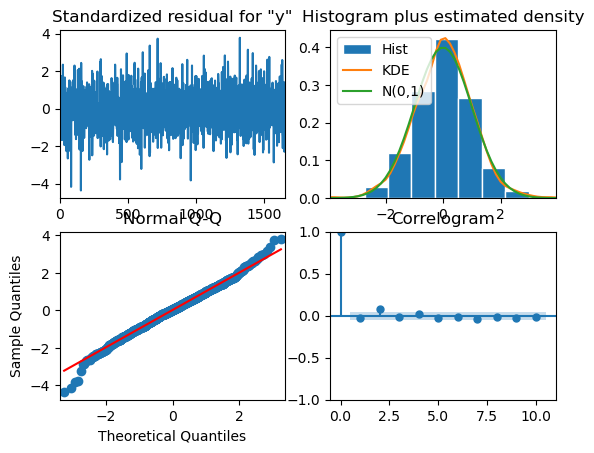

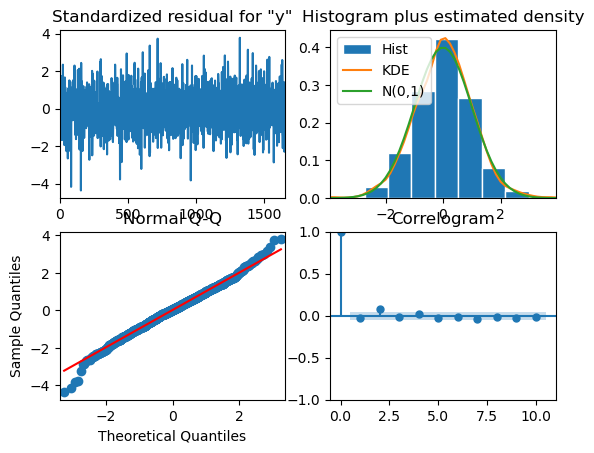

In [194]:
resultats.plot_diagnostics()

In [195]:

#data_test_ok_simple.index = data_test_ok_simple.index.get_level_values(0)


n_test = len(data_tes_ok)

pred_test = resultats.forecast(steps=n_test)
pred_test.index = data_tes_ok.index
pred_test

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


date           
2018-01-01  Jan    0.904255
            Feb    0.895688
            Mar    0.892838
            Apr    0.891890
            May    0.891574
                     ...   
2024-01-01  Aug    0.891417
            Sep    0.891417
            Oct    0.891417
            Nov    0.891417
            Dec    0.891417
Name: predicted_mean, Length: 84, dtype: float64

In [196]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


mae  = mean_absolute_error(data_tes_ok, pred_test)
rmse = np.sqrt(mean_squared_error(data_tes_ok, pred_test))

print("MAE :", mae)
print("RMSE :", rmse)


MAE : 0.15982417117034706
RMSE : 0.22391652078461036


In [213]:
model_sarima = SARIMAX(
    data_train_ok,
    order=(3,1,2),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarima = model_sarima.fit()
results_sarima.summary()

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                 1656
Model:             SARIMAX(3, 1, 2)x(1, 1, [1], 12)   Log Likelihood                1301.784
Date:                              Fri, 06 Feb 2026   AIC                          -2587.569
Time:                                      10:30:58   BIC                          -2544.408
Sample:                                           0   HQIC                         -2571.556
                                             - 1656                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3359      0.473     -0.710      0.478      -1.263       0.591
ar.L2          0.6076      0.226      2.690      0.007       0.165       1.050
ar.L3          0.1662      0.110      1.511      0.131      -0.049       0.382
ma.L1         -0.1456      0.472     -0.309      0.758      -1.070       0.779
ma.L2         -0.7904      0.456     -1.735      0.083      -1.683       0.103
ar.S.L12   -4.881e-06      0.004     -0.001      0.999      -0.007       0.007
ma.S.L12      -0.9569      0.008   -121.880      0.000      -0.972      -0.942
sigma2         0.0117      0.000     32.977      0.000       0.011       0.012
===================================================================================
Ljung-Box (L1) (Q):                   0.33   Jarque-Bera (JB):                40.96
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                             0.00
Prob(H) (two-sided):                  0.97   Kurtosis:                         3.78
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

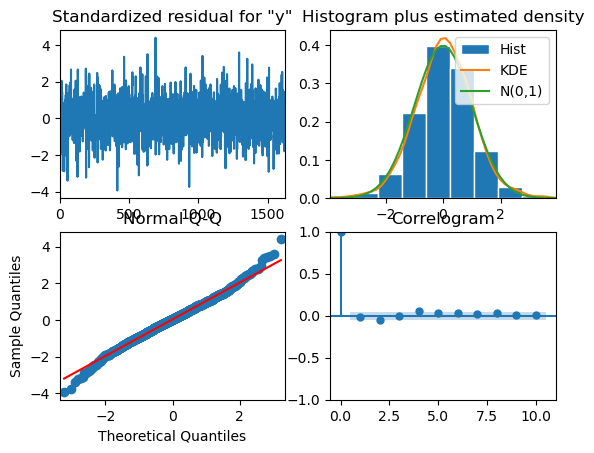

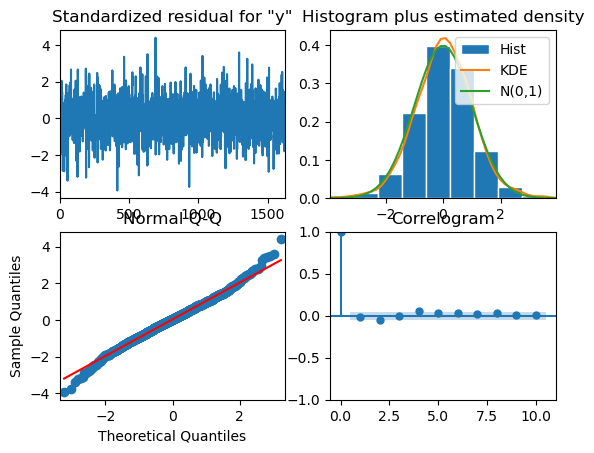

In [214]:
results_sarima.plot_diagnostics()

In [215]:
pred_sarima = results_sarima.forecast(steps=len(data_tes_ok))
pred_sarima.index = data_tes_ok.index
pred_sarima

C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\USER\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


date           
2018-01-01  Jan    0.954827
            Feb    0.972760
            Mar    1.003037
            Apr    0.940062
            May    0.917673
                     ...   
2024-01-01  Aug    1.036831
            Sep    1.029641
            Oct    1.056344
            Nov    1.065490
            Dec    1.038063
Name: predicted_mean, Length: 84, dtype: float64

In [216]:
mae  = mean_absolute_error(data_tes_ok, pred_sarima)
rmse = np.sqrt(mean_squared_error(data_tes_ok, pred_sarima))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 0.1365298367488085
RMSE : 0.16954798138631347


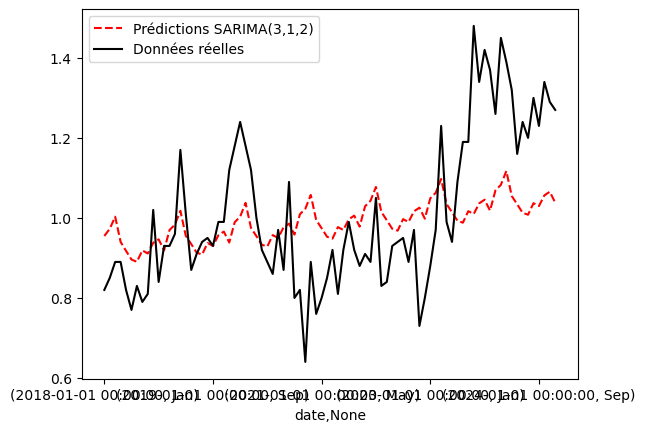

In [227]:


pred_sarima.plot(label="Prédictions SARIMA(3,1,2)", linestyle="--", color="red")
data_tes_ok.plot(label="Données réelles", color="black")

plt.legend()


Nous constatons que notre modèle SARIMA prédit les anomalies avec une erreur moyenne relativement faible :

MAE (Mean Absolute Error) : 0,1365

RMSE (Root Mean Squared Error) : 0,1695

Ces résultats suggèrent que la combinaison des modèles de séries temporelles avec d’autres modèles de machine learning pourrait permettre d’obtenir des prévisions encore plus précises. Cet aspect sera mis en perspective dans le cadre de notre travail.

Nous vous remercions pour votre attention. Vous trouverez ci-dessous une description très sommaire des séries temporelles.

**WAMBA FOGOUG VOLVIAN SILVANSIEN**

**Master  Data Science et Ingénierie Mathématique**

**Option Assurance et Finance, UDS | AUF**

# Description sommaire des séries temporelles

Les modèles de séries temporelles ont une particularité fondamentale : les observations ne sont pas indépendantes et identiquement distribuées (i.i.d.). En effet, les données sont fortement liées à la dimension temporelle, ce qui introduit une dépendance entre les observations successives.

Une série temporelle peut ainsi être définie comme une suite de variables aléatoires indexées par le temps, notée 
(𝑋𝑡)𝑡∈𝑍

Les modèles de séries temporelles reposent principalement sur deux structures fondamentales : les modèles autorégressifs (AR) et les modèles à moyenne mobile (MA).

Le **modèle AR(p) permet de prédire la valeur future d’un phénomène en fonction de ses valeurs passées. Il est particulièrement adapté aux phénomènes dont l’évolution est relativement lisse et progressive**, comme par exemple la température moyenne, qui ne varie pas brutalement d’une période à l’autre. Le choix de l’ordre 
p d’un modèle AR est généralement guidé par l’analyse de **la fonction d’autocorrélation partielle (PACF)**.

Le **modèle MA(q), quant à lui, modélise la valeur actuelle d’un phénomène comme une combinaison linéaire des chocs aléatoires passés (erreurs). Il est donc adapté aux phénomènes influencés par des chocs ponctuels**, tels que le taux de CO₂, qui peut subir des variations brusques dues par exemple à des incendies ou à des événements industriels. **L’ordre 
q est généralement identifié à l’aide de la fonction d’autocorrélation (ACF)**.

Dans la pratique, il est rare qu’un phénomène réel soit expliqué uniquement par un modèle AR ou MA. Les deux dynamiques étant souvent présentes simultanément, on utilise alors un **modèle ARMA(p, q)**, qui combine les composantes autorégressive et moyenne mobile.

Cependant, ces modèles supposent que la **série est stationnaire**. Or, de nombreuses séries réelles ne le sont pas. Pour remédier à ce problème, on applique une différenciation afin de rendre la série stationnaire. Cela conduit au modèle **ARIMA(p, d, q)**, où 
𝑑 représente le nombre de différenciations nécessaires.

Enfin, lorsque les données présentent une structure saisonnière, ou sont influencées par des variables exogènes, on utilise respectivement les **modèles SARIMA et SARIMAX**, qui étendent ARIMA en intégrant ces composantes supplémentaires.